In [1]:
import tensorflow as tf
from keras.src.regularizers import regularizers
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow import keras

I0000 00:00:1788503591.420353    5860 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788503591.450523    5860 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788503595.709794    5860 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788503622.358813    5860 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
dataset_path = "../datasets/flower_photos/"

In [3]:
IMG_SIZE = 224
IMG_CHANNELS = 3
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 10
CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

In [4]:
# creating an tensorflow dataset (including image size and batch)
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    shuffle = True,
    image_size = (IMG_SIZE,IMG_SIZE), # height and width
    batch_size = BATCH_SIZE,
)

Found 3670 files belonging to 5 classes.


E0000 00:00:1788503641.626429    5860 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1788503641.626777    6103 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1788503641.720408    5860 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
print(dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [6]:
class_names = dataset.class_names
class_names

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

In [7]:
dataset.take(1) # this return the first bacth from the dataset

<_TakeDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [8]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 224, 224, 3)
[3 1 2 2 3 4 1 1 2 1 3 2 4 2 2 3 2 4 1 2 3 1 2 3 0 3 4 2 2 1 3 4]


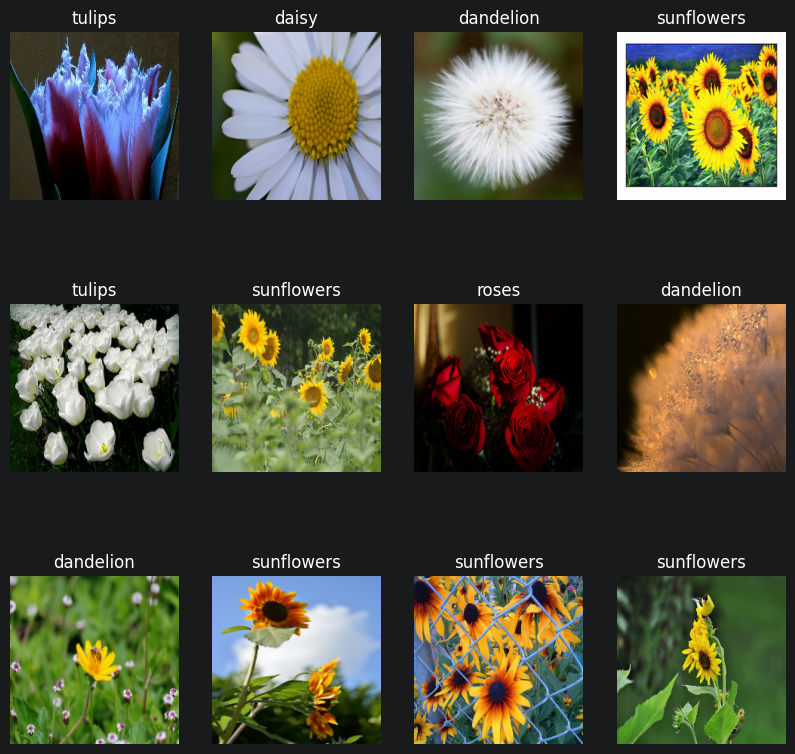

In [9]:
plt.figure(figsize=(10,10))  # optional
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)

        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis("off")
        plt.title(class_names[labels_batch[i]])

In [10]:
train_size = 0.8

In [11]:
def get_dataset_partitions(ds, train_size=0.8, val_size=0.1, test_size=0.1, shuffle=True, shuffle_size=100):
    assert(train_size + val_size + test_size == 1)


    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_size * ds_size)
    val_size = int(val_size * ds_size)
    test_size = int(test_size * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(test_size).skip(val_size).take(test_size)

    return train_ds, val_ds, test_ds

In [12]:
train_ds, val_ds, test_ds  = get_dataset_partitions(dataset)

In [13]:
len(test_ds)

11

In [14]:
train_ds.cache().shuffle(100).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds.cache().shuffle(100).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds.cache().shuffle(100).prefetch(buffer_size = tf.data.AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [15]:
for image_batch, labels_batch in train_ds.take(1):
    print(image_batch[0].numpy()/255)

I0000 00:00:1788503656.138698    6173 shuffle_dataset_op.cc:453] ShuffleDatasetV3:10: Filling up shuffle buffer (this may take a while): 15 of 100
I0000 00:00:1788503666.313141    6173 shuffle_dataset_op.cc:453] ShuffleDatasetV3:10: Filling up shuffle buffer (this may take a while): 29 of 100
I0000 00:00:1788503686.216687    6173 shuffle_dataset_op.cc:453] ShuffleDatasetV3:10: Filling up shuffle buffer (this may take a while): 55 of 100
I0000 00:00:1788503696.319108    6173 shuffle_dataset_op.cc:453] ShuffleDatasetV3:10: Filling up shuffle buffer (this may take a while): 69 of 100
I0000 00:00:1788503716.082147    6173 shuffle_dataset_op.cc:453] ShuffleDatasetV3:10: Filling up shuffle buffer (this may take a while): 96 of 100


[[[0.31423572 0.37885153 0.0857743 ]
  [0.2569828  0.33256304 0.05008003]
  [0.24224691 0.32486993 0.06242497]
  ...
  [0.6802024  0.6930773  0.5076734 ]
  [0.6815325  0.6960984  0.5314426 ]
  [0.6667267  0.68336326 0.5353843 ]]

 [[0.2817627  0.35118046 0.06449579]
  [0.29257703 0.36680672 0.08810525]
  [0.24989995 0.33186275 0.06155462]
  ...
  [0.6586231  0.6716181  0.48597386]
  [0.6738495  0.6888356  0.51586646]
  [0.66810703 0.6881351  0.5286614 ]]

 [[0.27771106 0.34562823 0.06204482]
  [0.31218487 0.3857643  0.10266107]
  [0.27190876 0.3504702  0.07480992]
  ...
  [0.6500189  0.6655649  0.4733176 ]
  [0.6671969  0.6859345  0.49375767]
  [0.6659561  0.6896355  0.5135553 ]]

 ...

 [[0.9306623  0.9417267  0.8771609 ]
  [0.9271409  0.9386555  0.87273914]
  [0.9123749  0.92441976 0.8487895 ]
  ...
  [0.7641059  0.7797922  0.67531043]
  [0.7681773  0.7859343  0.67714095]
  [0.7784317  0.79103667 0.712886  ]]

 [[0.91765714 0.92942184 0.8612545 ]
  [0.9256403  0.937405   0.86373556]


I0000 00:00:1788503719.152833    6173 shuffle_dataset_op.cc:483] Shuffle buffer filled.


In [16]:
tf.keras.Sequential([
    layers.Resizing(IMG_SIZE, IMG_SIZE),
    layers.Rescaling(1.0/255),
])

<Sequential name=sequential, built=False>

In [17]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

# technically the model has no hidden layers
# it has only one layer which is corresponds to its pixel values or pixel intensity
# at keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)), this flatten layer will have 224 * 224 * 3 perceptron nodes

/media/qs-ashish/DATA/ashish/core-python/.venv/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.3247 - loss: 4563.7861 - val_accuracy: 0.3864 - val_loss: 1456.5477
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.4181 - loss: 1492.8241 - val_accuracy: 0.5000 - val_loss: 851.4168
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4448 - loss: 1458.5199 - val_accuracy: 0.5284 - val_loss: 803.5686
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4867 - loss: 1173.5496 - val_accuracy: 0.5483 - val_loss: 854.4422
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.4247 - loss: 2270.1245 - val_accuracy: 0.4886 - val_loss: 1323.4724
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.4823 - loss: 1614.5371 - val_accuracy: 0.6193 - val_loss: 747.2548
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.5215 - loss: 1298.5526 - val_accuracy: 0.4801 - val_loss: 1761.9810
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.5109 - 

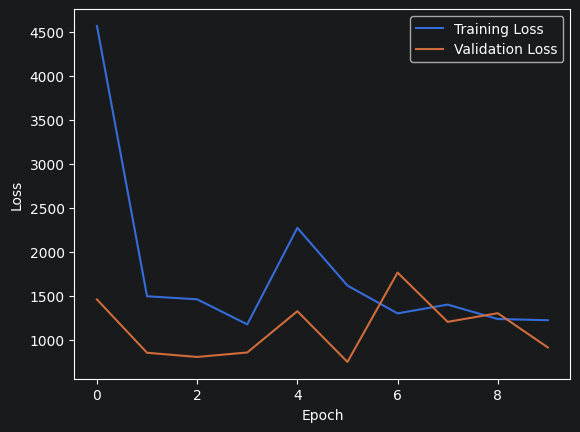

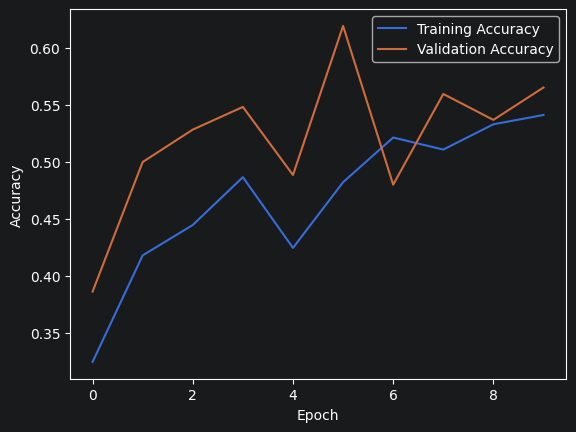

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [21]:
# more flutuations in the accuracy curve indicates that there is no better learning


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [14.402287..235.4166].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.70952].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..226.13895].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..244.3125].
Clipping input data to the valid range for

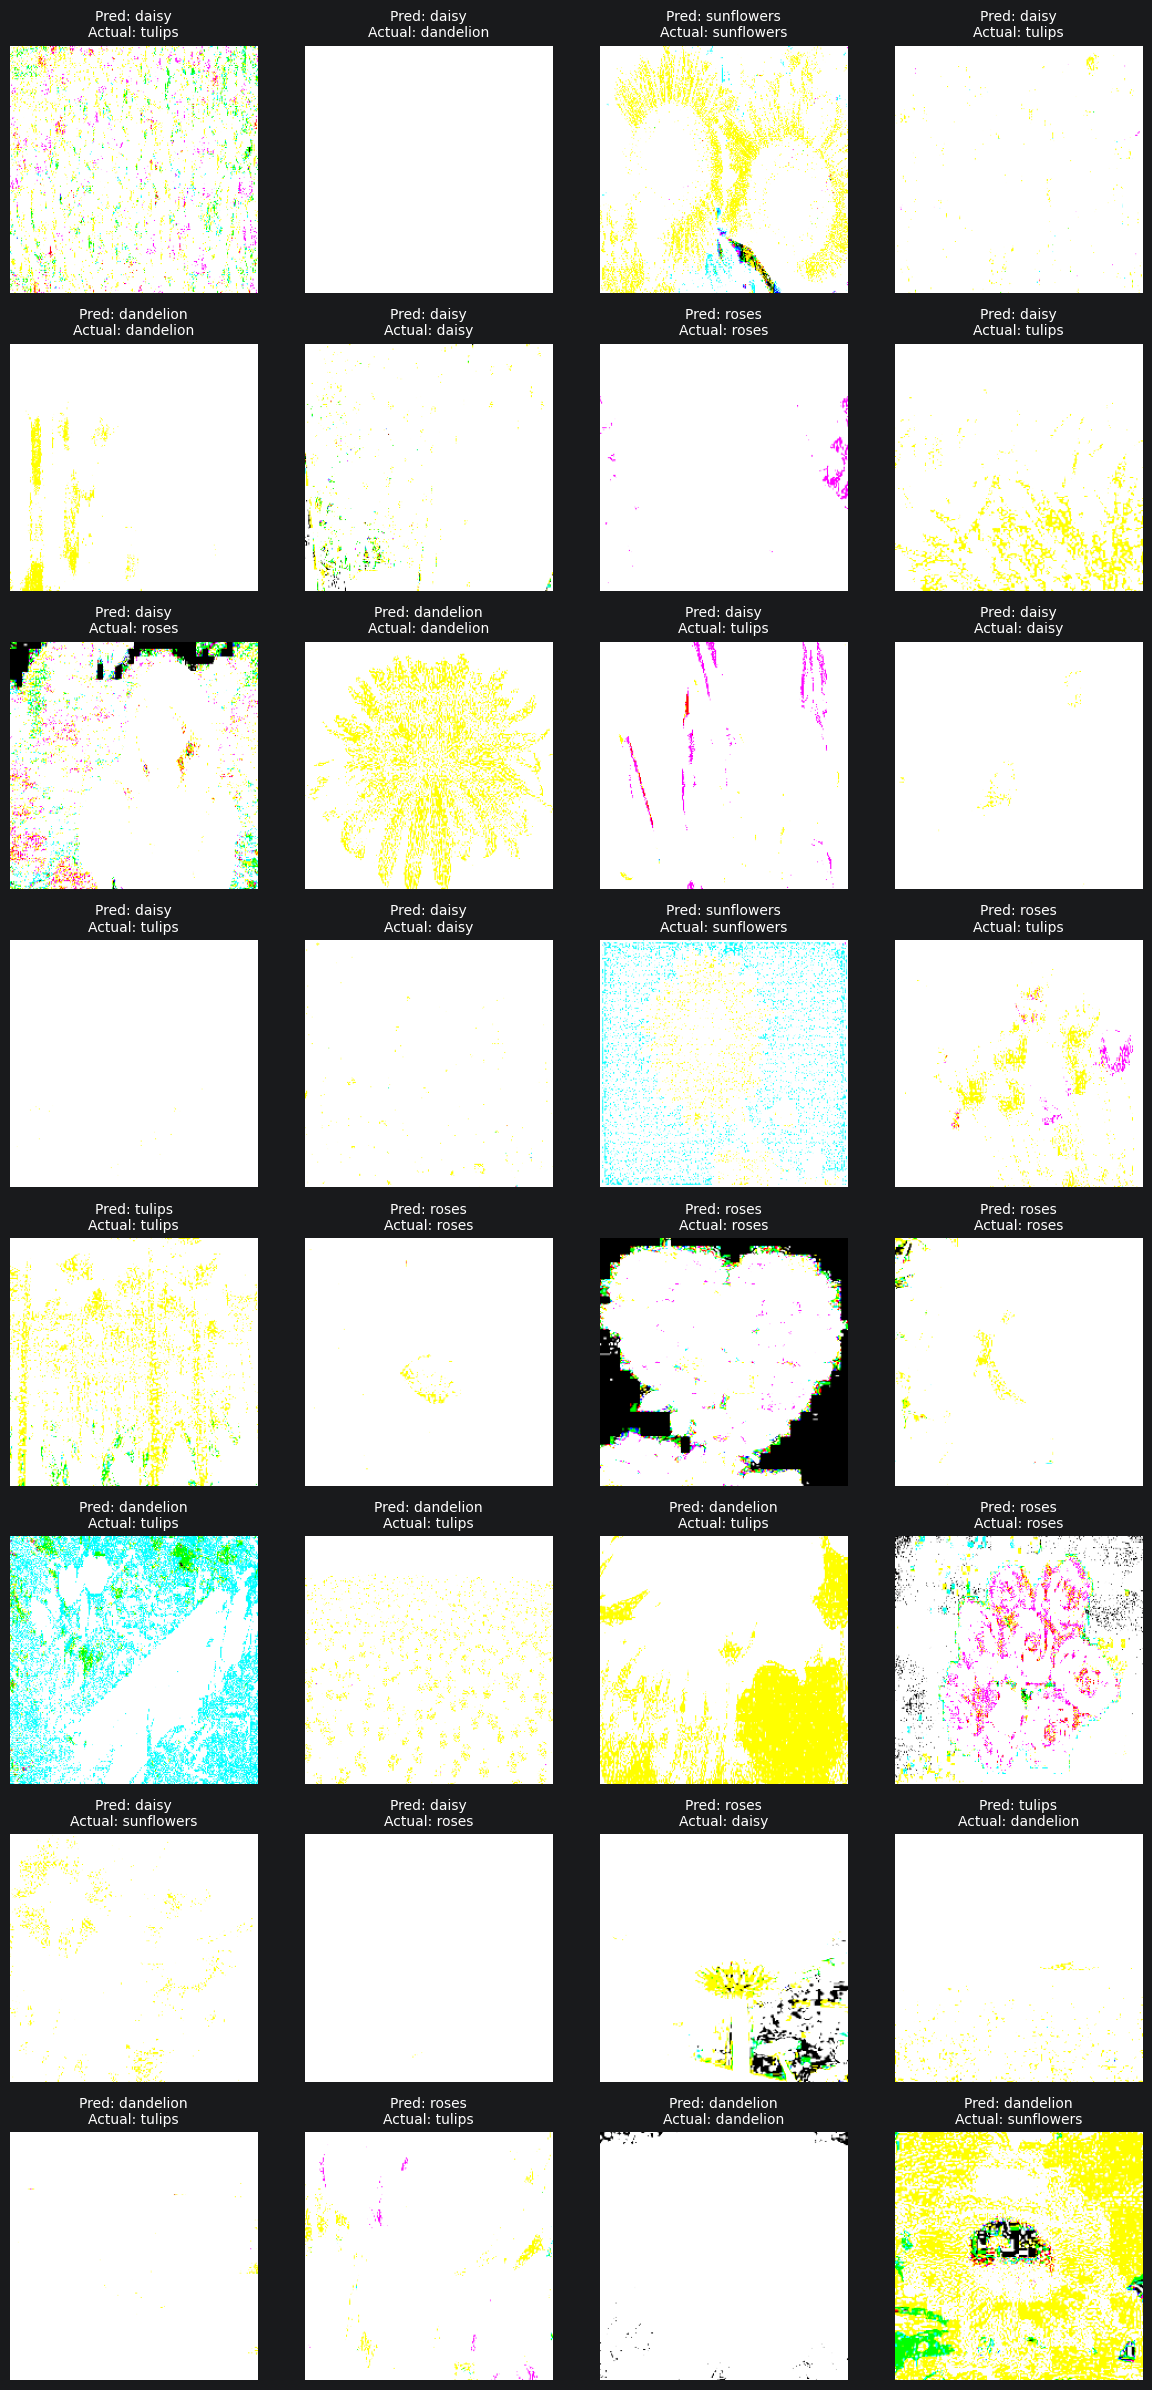

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Take exactly one batch from the evaluation dataset
for images, labels in val_ds.take(1):
    # Get model predictions for this batch
    batch_predictions = model.predict(images)
    predicted_indices = np.argmax(batch_predictions, axis=1)

    # Number of images in this batch
    num_images = images.shape[0]

    # Configure how many images to display per row
    num_cols = 4
    num_rows = math.ceil(num_images / num_cols)

    # Create a figure with a suitable size
    plt.figure(figsize=(12, 3 * num_rows))

    for i in range(num_images):
        plt.subplot(num_rows, num_cols, i + 1)

        # Display the image
        plt.imshow(images[i].numpy())
        plt.axis('off')

        # Get predicted and actual class names
        pred_class = CLASS_NAMES[predicted_indices[i]]
        actual_class = CLASS_NAMES[labels[i].numpy()]

        # Show both predicted and actual labels as title
        plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10)

    # Adjust spacing to avoid overlapping titles, etc.
    plt.tight_layout()
    plt.show()

In [23]:
# more fluctuations i

## Slighly better Neural network with two hidden layers

In [24]:
# we have one flatten layer and one hidden layer
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])

In [25]:
model.compile(
    # optimizer="adam",    # this uses default learning rate = 0.001
    optimizer = keras.optimizers.Adam(learning_rate=0.05), # use this synatx if we wants to mention learning rate as well

    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [26]:
# https://www.geeksforgeeks.org/deep-learning/why-relu-function-is-not-differentiable-at-x-0/
# relu function is continous but not differntiable at x = 0

In [27]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 169ms/step - accuracy: 0.2313 - loss: 150622.4219 - val_accuracy: 0.2102 - val_loss: 1.6089
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 175ms/step - accuracy: 0.2406 - loss: 1.6033 - val_accuracy: 0.2131 - val_loss: 1.6078
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 167ms/step - accuracy: 0.2423 - loss: 1.6027 - val_accuracy: 0.2784 - val_loss: 1.5917
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 167ms/step - accuracy: 0.2342 - loss: 1.6058 - val_accuracy: 0.2102 - val_loss: 1.6038
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 169ms/step - accuracy: 0.2342 - loss: 1.6058 - val_accuracy: 0.2310 - val_loss: 1.6088
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 163ms/step - accuracy: 0.2338 - loss: 1.6045 - val_accuracy: 0.2358 - val_loss: 1.6085
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 166ms/step - accuracy: 0.2351 - loss: 1.6065 - val_accuracy: 0.2188 - val_loss: 1.6089
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 184ms/step - accuracy: 0.2389 - loss: 1.6033 - val

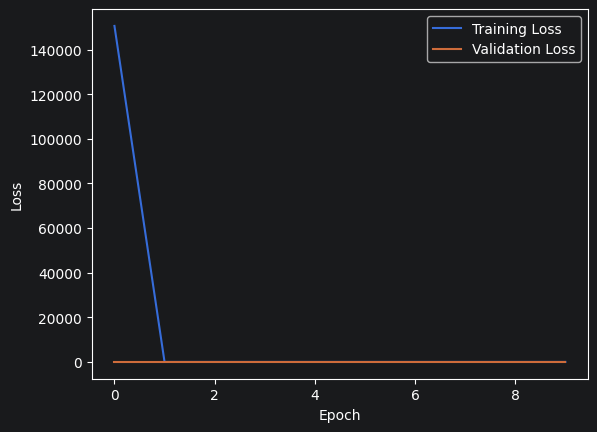

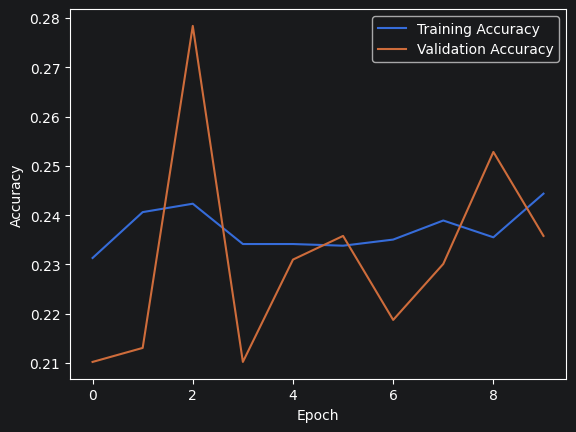

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [29]:
# hyperparametrs
# 1. Learning rate
# 2. Image size
# 3. Batch size
# 4. optimisers
# 5. number of epochs
# 6. Loss function
# 7. number of hiiden layers
# 8. numer of neurons in each layers

# Parametrs
# 1. Weight
# 2. Biase

# Note: when we train a neural network then we train to obtain the best (optimal weight and biases) but when we search for the NN architecture then we look for the hyperparameters

## if we wants to define regulization layer

In [30]:
# adding regularazation layer

In [31]:
from tensorflow.keras.regularizers import l1_l2

regularizers = l1_l2(0, 0.001)
# lambda for l1 reguliser is 0
# lambda for l2 regulasier is 0.01
# means we are just using l2 reguliser

In [32]:

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)),
    keras.layers.Dense(128, kernel_regularizer=regularizers,activation="relu"),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])


# kernel_regularizer parameter is used for the regularization layer adding

## Code to add the dropout layer in the model

In [33]:

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)),
    keras.layers.Dense(128,activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])


# important thing to understand is that Dropout is applied to the output of the layer immediately before it, not to the next layer

## Early Stoping
    - # we use easrly stoping at the time of model training and not at the time of model architecture defining (because early stoping happens at the time of training)

In [34]:
# we use easrly stoping at the time of model training and not at the time of model architecture defining (because early stoping happens at the time of training)

In [35]:
# Suppos we are defining a model with L2 Regulariastion as follows
from tensorflow.keras.regularizers import l1_l2

regularizers = l1_l2(0, 0.001)

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)),
    keras.layers.Dense(128, kernel_regularizer=regularizers,activation="relu"),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])

In [ ]:
# code for early stoping logic
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,   # atleast you should wait for 5 epochs before early stoping
            restore_best_weights=True  # go back to the prevois best weigts
        )
    ]
)

## Code for batch normalization

In [37]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)),

    keras.layers.Dense(128),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),

    keras.layers.Dense(64),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu"),

    keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])